Task 3 - USA Real Estate

I chose the USA Real Estate dataset from Kaggle to look at how house prices compare with size, bedrooms, bathrooms, and state. The current file has 2,226,382 rows, so it meets the 100,000-row requirement. It also has missing values and some unusually large numbers to check.

The file used here keeps seven columns: status, price, bed, bath, acre_lot, state, and house_size. Price is in dollars, lot size is in acres, and house size is in square feet. Addresses, broker information, city, ZIP code, and previous sale dates were left out of this copy. All original rows were kept before cleaning. There are no names, contact details, or exact addresses in the analysis file.

Upload real_estate_analysis.csv.zip to the main Files area in Colab, then run the cells in order. It does not need to be unzipped. You can also keep it in MyDrive/AI101_Assignment2 and mount Google Drive in Colab. The code checks both locations and the current folder.

Dataset: https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset
Reference notebook: https://www.kaggle.com/code/qusaybtoush1990/usa-real-estate-predict-price



Import libraries

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

numpy imports tools for calculations. pandas imports tools for loading and working with data. matplotlib.pyplot imports tools for making charts. seaborn imports tools for statistical charts. Path helps find the data file.


Load the data

In [15]:
my_df = pd.read_csv('/content/real_estate_analysis.csv.zip', compression='zip', low_memory=False)
display(my_df.head())

,status,price,bed,bath,acre_lot,state,house_size
0,for_sale,105000.0,3.0,2.0,0.12,Puerto Rico,920.0
1,for_sale,80000.0,4.0,2.0,0.08,Puerto Rico,1527.0
2,for_sale,67000.0,2.0,1.0,0.15,Puerto Rico,748.0
3,for_sale,145000.0,4.0,2.0,0.10,Puerto Rico,1800.0
4,for_sale,65000.0,6.0,2.0,0.05,Puerto Rico,NaN


paths lists the places where the data file might be stored. data_path picks the first location where the file exists, or None if it cannot find it. The if statement checks whether the file is missing. raise shows a message explaining where to upload it if needed. read_csv loads the CSV inside the ZIP into my_df. compression tells pandas it is a ZIP, and low_memory=False helps it read column types consistently. head displays the first five rows.

The output is a preview of the seven columns and their values. Each row is a listing record, not necessarily a different house.

Check the size and columns

In [16]:
size = my_df.size
shape = my_df.shape
print(f"Rows: {shape[0]:,}; columns: {shape[1]}; cells: {size:,}")
my_df.info(show_counts=True)
print("Listing statuses:")
print(my_df["status"].value_counts(dropna=False))

Rows: 2,226,382; columns: 7; cells: 15,584,674
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 7 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   status      2226382 non-null  object 
 1   price       2224841 non-null  float64
 2   bed         1745065 non-null  float64
 3   bath        1714611 non-null  float64
 4   acre_lot    1900793 non-null  float64
 5   state       2226374 non-null  object 
 6   house_size  1657898 non-null  float64
dtypes: float64(5), object(2)
memory usage: 118.9+ MB
Listing statuses:
status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64


size counts all the cells, including missing ones. shape gets the number of rows and columns. The first print shows these counts with commas. info shows each column's type, nonmissing count, and the memory used. The next print adds a heading. value_counts counts each listing status, including missing labels if there are any.

There are 2,226,382 rows, seven columns, and 15,584,674 cells. The statuses include for_sale, sold, and ready_to_build. The analysis below uses only for_sale listings so these groups are not mixed together.

Statistics and missing values

In [17]:
numeric_cols = ["price", "bed", "bath", "acre_lot", "house_size"]
display(my_df[numeric_cols].describe().T)
missing_report = pd.DataFrame({"missing_count": my_df.isna().sum(), "missing_percent": my_df.isna().mean() * 100})
display(missing_report.round(2))
print("Repeated retained profiles:", f"{my_df.duplicated().sum():,}")

,count,mean,std,min,25%,50%,75%,max
price,2224841.0,524195.519291,2.138893e+06,0.0,165000.00,325000.00,550000.00,2.147484e+09
bed,1745065.0,3.275841,1.567274e+00,1.0,3.00,3.00,4.00,4.730000e+02
bath,1714611.0,2.496440,1.652573e+00,1.0,2.00,2.00,3.00,8.300000e+02
acre_lot,1900793.0,15.223027,7.628238e+02,0.0,0.15,0.26,0.98,1.000000e+05
house_size,1657898.0,2714.471335,8.081635e+05,4.0,1300.00,1760.00,2413.00,1.040400e+09


,missing_count,missing_percent
status,0,0.00
price,1541,0.07
bed,481317,21.62
bath,511771,22.99
acre_lot,325589,14.62
state,8,0.00
house_size,568484,25.53


Repeated retained profiles: 149,214


numeric_cols lists the five numerical columns. describe shows their counts, averages, standard deviations, minimums, quartiles, and maximums. The .T turns the table so each variable has its own row. missing_report makes a table of missing counts and percentages: isna marks missing cells, sum counts them, and mean times 100 gives the percentage. round displays this table to two decimal places. duplicated counts rows with the same seven values, and print shows that count.

Bedrooms, bathrooms, and house size have many missing values. There are 149,214 repeated seven-column profiles. These are not automatically removed because different houses can have the same features. The original 12-column file had no exact duplicate rows.

Clean the values

In [18]:
clean_df = my_df.copy()
clean_df[numeric_cols] = clean_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
clean_df[numeric_cols] = clean_df[numeric_cols].replace([np.inf, -np.inf], np.nan)
clean_df[numeric_cols] = clean_df[numeric_cols].mask(clean_df[numeric_cols] < 0)
clean_df["state"] = clean_df["state"].astype("string").str.strip().replace("", pd.NA)
clean_df["status"] = clean_df["status"].astype("string").str.strip().str.lower()
display(clean_df.isna().sum().to_frame("missing_after_normalization"))

,missing_after_normalization
status,0
price,1541
bed,481317
bath,511771
acre_lot,325589
state,8
house_size,568484


copy makes a separate table for cleaning. to_numeric converts the measurement columns to numbers and marks values it cannot convert as missing. replace changes positive and negative infinity to missing values. mask does the same for negative measurements. The state line changes names to text, removes extra spaces, and treats empty names as missing. The status line removes spaces and makes the labels lowercase. The last line displays the missing counts after these changes.

This makes the values consistent before filtering. Missing values are not replaced with zero, since zero would mean something different. Very large positive values are kept for review.

Choosing
 the rows to analyze

In [19]:
analysis_df = clean_df.loc[clean_df["status"].eq("for_sale")].copy()
for_sale_rows = len(analysis_df)
required = ["price", "bed", "bath", "house_size", "state"]
analysis_df = analysis_df.dropna(subset=required)
complete_rows = len(analysis_df)
positive = (analysis_df[["price", "bed", "bath", "house_size"]] > 0).all(axis=1)
analysis_df = analysis_df.loc[positive].copy()
audit = pd.DataFrame({"stage": ["All source records", "For-sale records", "Required fields complete", "Positive required measurements"], "rows_remaining": [len(my_df), for_sale_rows, complete_rows, len(analysis_df)]})
display(audit)
print(f"Retained {len(analysis_df) / len(my_df):.2%} of all source rows.")
display(analysis_df[numeric_cols].describe().T)
display(analysis_df.isna().sum().to_frame("remaining_missing"))

,stage,rows_remaining
0,All source records,2226382
1,For-sale records,1389306
2,Required fields complete,908565
3,Positive required measurements,908558


Retained 40.81% of all source rows.


,count,mean,std,min,25%,50%,75%,max
price,908558.0,635142.639601,2.886850e+06,1.0,239000.00,380000.00,624500.00,2.147484e+09
bed,908558.0,3.317997,1.557195e+00,1.0,3.00,3.00,4.00,4.440000e+02
bath,908558.0,2.579768,1.547577e+00,1.0,2.00,2.00,3.00,4.600000e+02
acre_lot,750932.0,13.483890,8.029227e+02,0.0,0.14,0.23,0.54,1.000000e+05
house_size,908558.0,2145.104011,4.962931e+03,4.0,1328.00,1804.00,2504.00,1.560780e+06


,remaining_missing
status,0
price,0
bed,0
bath,0
acre_lot,157626
state,0
house_size,0


The first line keeps only for_sale rows in a new table. for_sale_rows counts those rows. required lists the columns needed for the analysis. dropna removes rows missing any of those fields. complete_rows counts what is left. positive checks that price, bedrooms, bathrooms, and house size are all above zero. The next line keeps rows that pass that check. audit puts the row count from each step into a table. display shows that table. print shows the percentage of original rows kept. describe shows statistics for the cleaned data. The last display shows any remaining missing values.

The data go from 2,226,382 total rows to 1,389,306 for-sale rows, then 908,565 complete rows, and finally 908,558 rows with positive measurements. That is 40.81% of the original data. Lot area still has 157,626 missing values, which are left as missing. These filters exclude land and some other listings, so the results do not describe every property in the original file.

Price histogram

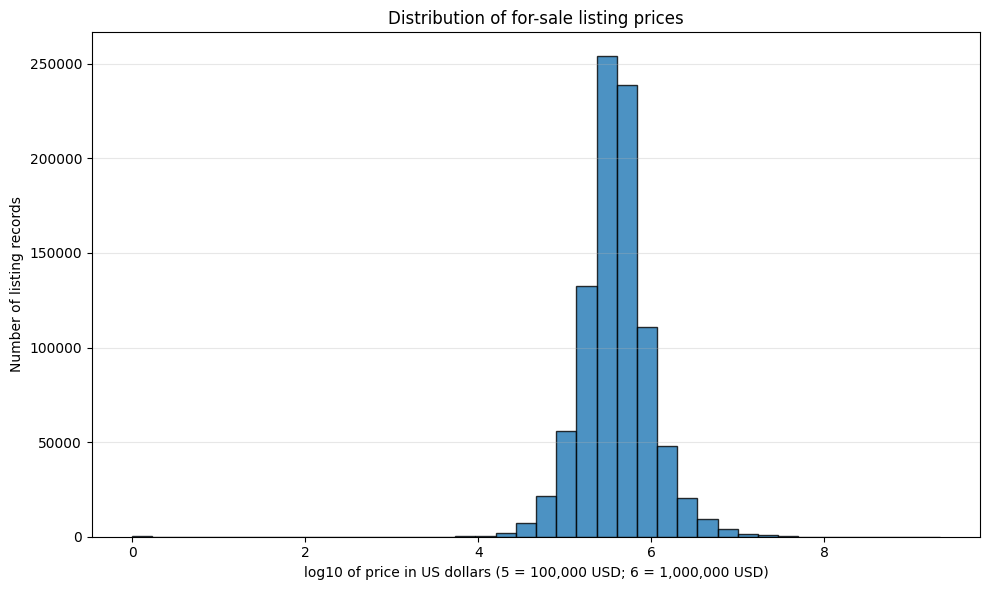

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(np.log10(analysis_df["price"]), bins=40, edgecolor="black", alpha=0.8)
plt.title("Distribution of for-sale listing prices")
plt.xlabel("log10 of price in US dollars (5 = 100,000 USD; 6 = 1,000,000 USD)")
plt.ylabel("Number of listing records")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("real_estate_price_histogram.png", dpi=140)
plt.show()

figure sets the chart size in inches. hist makes 40 bins with black borders and some transparency. log10 makes the wide range of prices easier to see; 5 means 100,000 dollars and 6 means 1,000,000 dollars. title adds the heading. xlabel explains the price scale. ylabel labels the number of records. grid adds faint horizontal lines. tight_layout adjusts spacing. savefig saves the image at 140 dots per inch, and show displays it.

The histogram shows how often prices fall into each range. Most listings are in the middle, with fewer very expensive listings. The bins cover equal steps in log price, not equal dollar amounts.

Prices by state

,count,median,mean
state,,,
Florida,113567,399900.0,766053.35
Texas,86227,353000.0,490942.93
California,75011,700000.0,1228152.34
New York,44673,514000.0,1256968.70
Illinois,37078,279900.0,402172.25
Pennsylvania,32509,285600.0,392638.61
Georgia,30841,350000.0,454114.42
Ohio,26538,209000.0,275845.31


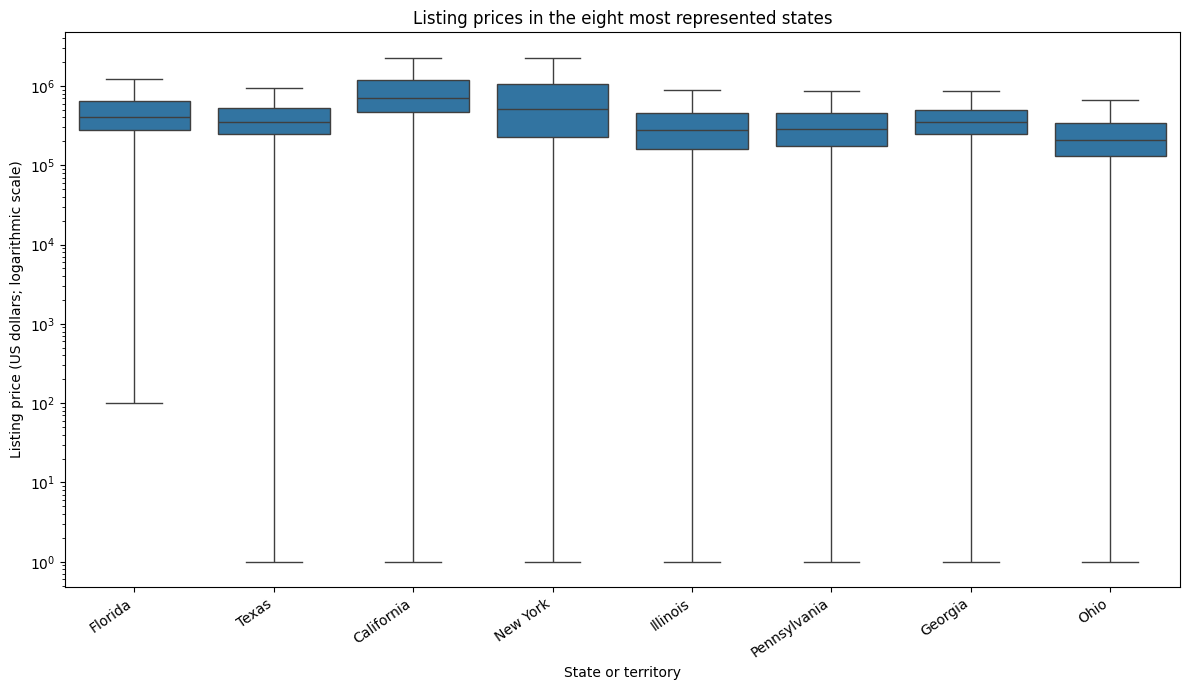

In [21]:
top_states = analysis_df["state"].value_counts().head(8).index
state_df = analysis_df.loc[analysis_df["state"].isin(top_states)]
state_summary = state_df.groupby("state")["price"].agg(["count", "median", "mean"]).reindex(top_states)
display(state_summary.round(2))
plt.figure(figsize=(12, 7))
sns.boxplot(data=state_df, x="state", y="price", order=top_states, showfliers=False)
plt.yscale("log")
plt.title("Listing prices in the eight most represented states")
plt.xlabel("State or territory")
plt.ylabel("Listing price (US dollars; logarithmic scale)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig("real_estate_state_boxplot.png", dpi=140)
plt.show()

top_states finds the eight states or territories with the most listings. state_df keeps those groups for the chart. state_summary calculates their counts, medians, and averages in the same order. display shows the table rounded to two decimal places. figure sets the chart size. boxplot compares prices by state and hides individual outlier dots to keep it readable; those records are still included in the calculations. yscale uses a log scale for prices. title adds the heading. xlabel labels the states, and ylabel explains the price axis. xticks tilts the names and lines them up to the right. tight_layout adjusts spacing. savefig saves the chart, and show displays it.

The line in each box is the median, and the box covers the middle 50% of prices. California has a higher median than the other seven groups shown. These are the most common states in this filtered dataset, not a ranking of all US states.

Check for outliers

In [22]:
price_mean = analysis_df["price"].mean()
price_std = analysis_df["price"].std()
z_scores = np.abs((analysis_df["price"] - price_mean) / price_std)
outliers = analysis_df.loc[z_scores > 3]
print(f"Z-score flags: {len(outliers):,} ({len(outliers) / len(analysis_df):.2%}); upper cutoff: ${price_mean + 3 * price_std:,.2f}")
display(outliers.nlargest(10, "price")[["state", "price", "bed", "bath", "house_size"]])
q1, q3 = analysis_df["price"].quantile([0.25, 0.75])
iqr = q3 - q1
iqr_flags = (analysis_df["price"] < q1 - 1.5 * iqr) | (analysis_df["price"] > q3 + 1.5 * iqr)
print(f"IQR flags: {iqr_flags.sum():,} ({iqr_flags.mean():.2%}); upper fence: ${q3 + 1.5 * iqr:,.2f}")

Z-score flags: 3,041 (0.33%); upper cutoff: $9,295,691.60


,state,price,bed,bath,house_size
221994,California,2.147484e+09,2.0,2.0,885.0
72903,New York,8.750000e+08,9.0,2.0,2440.0
1288464,California,5.150000e+08,2.0,2.0,1048.0
105334,New York,1.690000e+08,6.0,9.0,8255.0
1258584,California,1.650000e+08,14.0,27.0,56500.0
1307430,California,1.600000e+08,10.0,21.0,14189.0
490791,Florida,1.500000e+08,12.0,21.0,19919.0
105368,New York,1.350000e+08,5.0,6.0,8055.0
511759,Florida,1.150000e+08,7.0,13.0,15306.0
1307450,California,1.090000e+08,3.0,4.0,2514.0


IQR flags: 78,166 (8.60%); upper fence: $1,202,750.00


price_mean gets the average price. price_std gets the sample standard deviation. z_scores calculates each price's distance from the average in standard deviations, using absolute values. outliers keeps scores above 3. print shows the count, percentage, and upper cutoff. display shows the ten highest flagged prices with their property features. quantile gets the 25th and 75th percentiles. iqr subtracts them to get the spread of the middle 50%. iqr_flags checks for prices below or above the 1.5-IQR limits. The last print shows the count, percentage, and upper limit for this second method.

The Z-score method flags 3,041 records, while the IQR method flags 78,166. Very large prices can raise the average and standard deviation, which affects the Z-score results. A flagged price is not automatically wrong, so these records are kept instead of deleted.

House size and price

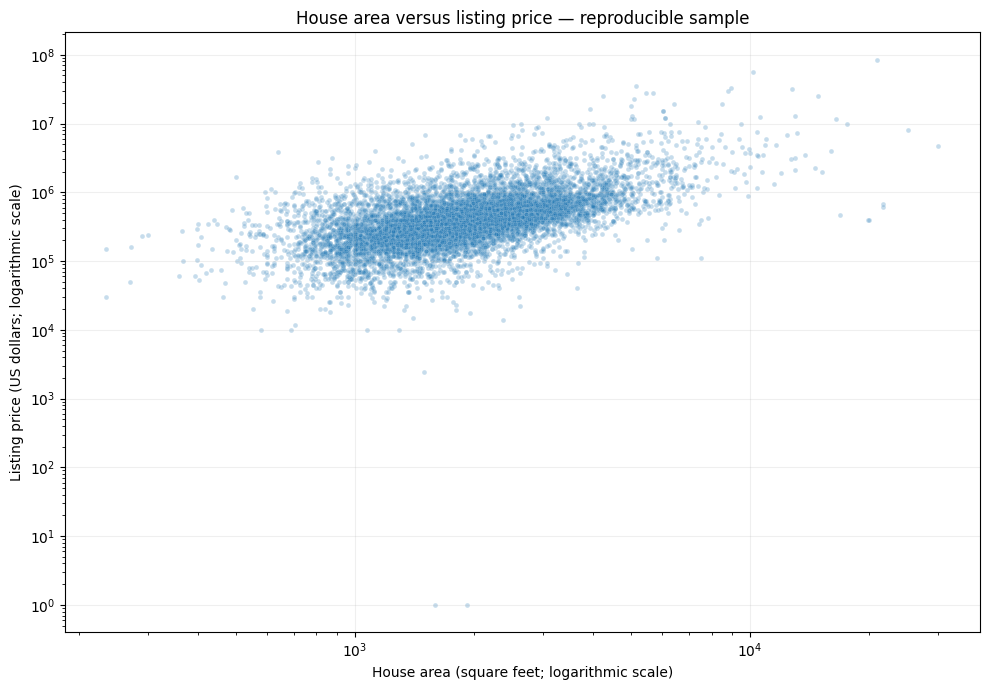

In [23]:
plot_sample = analysis_df.sample(n=min(10000, len(analysis_df)), random_state=42)
plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_sample, x="house_size", y="price", alpha=0.25, s=12)
plt.xscale("log")
plt.yscale("log")
plt.title("House area versus listing price — reproducible sample")
plt.xlabel("House area (square feet; logarithmic scale)")
plt.ylabel("Listing price (US dollars; logarithmic scale)")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("real_estate_size_price_scatter.png", dpi=140)
plt.show()

sample picks up to 10,000 records so the chart is not too crowded. random_state=42 makes the selection repeatable. figure sets the chart size. scatterplot puts house size on the bottom axis and price on the side axis, with small transparent dots. xscale and yscale use log scales to fit the wide ranges. title adds the heading. xlabel labels house size in square feet. ylabel labels price in dollars. grid adds faint lines. tight_layout adjusts spacing. savefig saves the chart, and show displays it.

The points generally move upward, meaning larger houses tend to have higher prices, but there is a lot of variation. Only this plot uses a sample. The statistics still use all 908,558 cleaned records. The pattern does not prove that size alone determines price.

Correlation heatmap

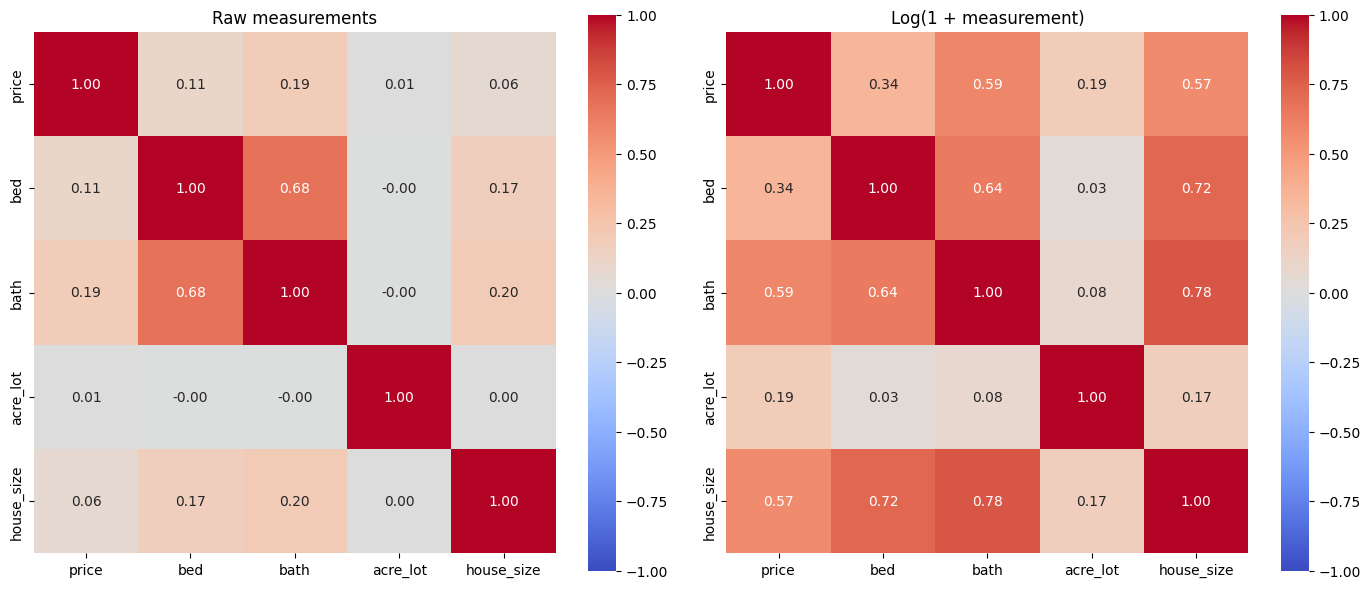

,raw_price_correlation,log_price_correlation
price,1.000,1.000
bed,0.107,0.344
bath,0.188,0.590
acre_lot,0.008,0.189
house_size,0.064,0.567


In [24]:
correlation = analysis_df[numeric_cols].corr()
log_correlation = np.log1p(analysis_df[numeric_cols]).corr()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, center=0, square=True, ax=axes[0])
axes[0].set_title("Raw measurements")
sns.heatmap(log_correlation, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, center=0, square=True, ax=axes[1])
axes[1].set_title("Log(1 + measurement)")
plt.tight_layout()
plt.savefig("real_estate_correlation_heatmaps.png", dpi=140)
plt.show()
display(pd.DataFrame({"raw_price_correlation": correlation["price"], "log_price_correlation": log_correlation["price"]}).round(3))

correlation calculates how the numerical columns relate using Pearson correlation. log_correlation does the same after log1p takes the log of one plus each value, which reduces the influence of very large numbers and allows zero lot areas. subplots makes two charts side by side. The first heatmap shows the original correlations with numbers rounded to two decimal places and colors ranging from -1 to 1. set_title labels that chart. The second heatmap shows the log-transformed correlations using the same colors and scale. Its set_title adds the second heading. tight_layout adjusts spacing. savefig saves both charts, and show displays them. The last display puts the correlations with price into a table rounded to three decimal places.

Values near 1 or -1 show strong positive or negative linear relationships; values near zero show weak ones. Price and house size have a correlation of 0.064 using the original values and 0.567 after the log transformation. This shows how the scale and extreme values affect the result. Missing lot areas are excluded for each pair that uses that column. These relationships do not prove cause and effect.

Results

In [25]:
print(f"Source records: {len(my_df):,}; analyzed for-sale records: {len(analysis_df):,}.")
print(f"Median asking price: ${analysis_df["price"].median():,.0f}; mean asking price: ${analysis_df["price"].mean():,.0f}.")
print(f"Median reported house area: {analysis_df["house_size"].median():,.0f} square feet.")
print(f"Raw price/area correlation: {correlation.loc["price", "house_size"]:.3f}; log-transformed correlation: {log_correlation.loc["price", "house_size"]:.3f}.")
print(f"Price records flagged by |Z| > 3: {len(outliers):,}.")

Source records: 2,226,382; analyzed for-sale records: 908,558.
Median asking price: $380,000; mean asking price: $635,143.
Median reported house area: 1,804 square feet.
Raw price/area correlation: 0.064; log-transformed correlation: 0.567.
Price records flagged by |Z| > 3: 3,041.


The first print shows the original and cleaned row counts. The second shows the median and average price. The third shows median house size. The fourth compares the original and log-transformed price-size correlations. The last print shows the number of prices flagged by the Z-score rule.

There are 908,558 listings after cleaning. The median price is 380,000 dollars, the average is about 635,143 dollars, and the median house size is 1,804 square feet. The average price is higher than the median because high prices pull it upward.

Summary

The biggest issues were missing values and some unusually large measurements. After keeping for-sale listings with the required information, 908,558 rows were left. The median price was 380,000 dollars. Prices differed across states, and larger houses generally had higher prices in the scatter plot.

The original and log-transformed correlations were quite different, so extreme values matter when interpreting the results. I kept flagged prices instead of assuming they were errors. Missing lot sizes were also left as missing instead of being filled with zero.

These results describe the listings included in this file. They are not current prices for every house in the US, and the filters leave out many incomplete listings. Repeated listings may also remain because the reduced file does not identify individual properties. This is an analysis of the data, not a tested price-prediction model.

Sources: the Kaggle dataset and reference notebook linked at the top, plus the instructor's finance notebook for the analysis steps. The source file was downloaded September 16, 2026. The seven-column ZIP keeps all original rows before the cleaning shown here.